# Exploratory Data Analysis

- **Dataset:** `piebro/deutsche-bahn-data` (Hugging Face, CC BY 4.0; source: Deutsche Bahn Timetables API)
- **Scope of this notebook:** exploration only.

The goal of EDA is *not* to reach a final conclusion. It is to learn the data's shape, catch its traps, and decide which one question the analysis should answer next.

**Definitions (matching Deutsche Bahn's own convention):**
- A stop is *on time* if arrival delay `< 6` minutes.
- Cancellations are reported **separately** from delay, never averaged into it (a cancelled stop has no delay value).

This notebook helps us conclude:
1. What the EDA established?
2. What are the data's limitations?
3. What's the question that the analysis will pursue?

## 0. Setup

In [1]:
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path("/Users/swarnavabanerjee/Documents/Old Files/ML Projects/db-analysis/data/monthly_processed_data")
DATA_GLOB = str(DATA_DIR / "*.parquet")
ANALYSIS_START, ANALYSIS_END = "2026-01-01", "2026-07-01"

MAJOR_TYPES = ("ICE", "IC", "EC", "RE", "RB", "S")

con = duckdb.connect()

## 1. Data shape and scale

In [3]:
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{DATA_GLOB}')").df()

,column_name,column_type,null,key,default,extra
0,station_name,VARCHAR,YES,None,None,None
1,xml_station_name,VARCHAR,YES,None,None,None
2,eva,VARCHAR,YES,None,None,None
3,train_number,VARCHAR,YES,None,None,None
4,line_number,VARCHAR,YES,None,None,None
5,final_destination_station,VARCHAR,YES,None,None,None
6,delay_in_min,INTEGER,YES,None,None,None
7,time,TIMESTAMP_NS,YES,None,None,None
8,is_canceled,BOOLEAN,YES,None,None,None
9,train_type,VARCHAR,YES,None,None,None


In [4]:
con.execute(f"""
    SELECT count(*) AS total_rows,
        count(*) FILTER (WHERE time >= '{ANALYSIS_START}' AND time <'{ANALYSIS_END}') AS rows_in_window
    FROM read_parquet('{DATA_GLOB}')
""").df()

,total_rows,rows_in_window
0,162403191,87649938


## 2. Punctuality by service type

Compare on-time performance across the major service categories. Long-distance services
are expected to trail regional ones.

In [5]:
by_type = con.execute(f"""
    SELECT
        train_type,
        count(*) AS stops,
        round(100.0 * avg((delay_in_min < 6)::int), 1) AS on_time_pct,
        round(avg(delay_in_min), 2) AS mean_delay_min
    FROM read_parquet('{DATA_GLOB}')
    WHERE NOT is_canceled
      AND train_type IN {MAJOR_TYPES}
      AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    GROUP BY train_type
    ORDER BY on_time_pct
""").df()
by_type

,train_type,stops,on_time_pct,mean_delay_min
0,ICE,951518,56.7,11.78
1,EC,25062,57.1,13.64
2,IC,300957,59.1,10.05
3,RE,7895346,77.3,4.50
4,RB,10439542,86.8,2.73
5,S,37270481,88.0,2.47


**Observation.** Long-distance services (ICE, IC, EC) are less punctual than
regional services (RE, RB, S). This is consistent with the idea that longer routes accumulate
delay. The question the analysis will test directly.

*Note:* the full dataset also contains many small private operators that post ~99% on-time
rates on short, uncongested routes. They are excluded here on purpose. They are real but
uninformative, and including them would distort the comparison.

## 3. Punctuality by hour of day

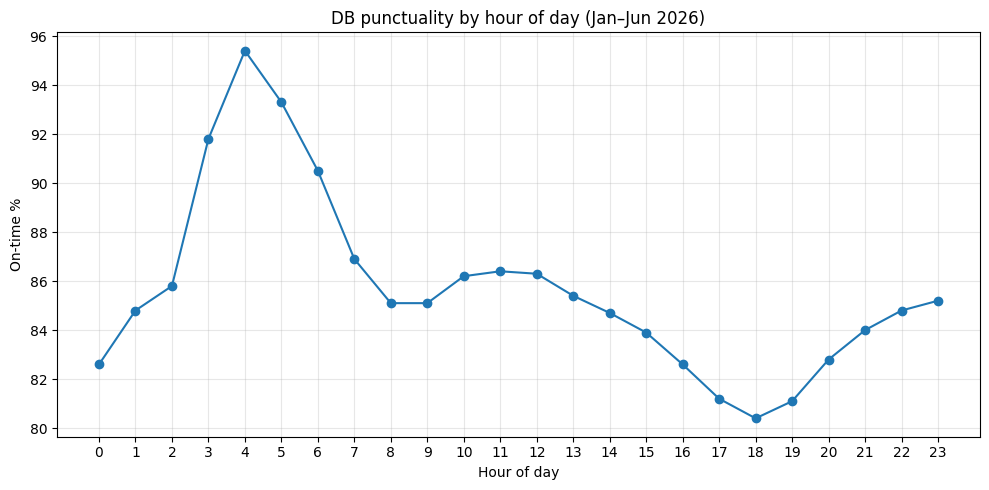

,hour_of_day,on_time_pct,stops
0,0,82.6,1255092
1,1,84.8,849048
2,2,85.8,364783
3,3,91.8,335633
4,4,95.4,1268217
5,5,93.3,3161971
6,6,90.5,4238228
7,7,86.9,4636747
8,8,85.1,4530877
9,9,85.1,4397244


In [6]:
by_hour = con.execute(f"""
    SELECT
        hour(time) AS hour_of_day,
        round(100.0 * avg((delay_in_min < 6)::int), 1) AS on_time_pct,
        count(*) AS stops
    FROM read_parquet('{DATA_GLOB}')
    WHERE NOT is_canceled
      AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

plt.figure(figsize=(10, 5))
plt.plot(by_hour["hour_of_day"], by_hour["on_time_pct"], marker="o")
plt.xlabel("Hour of day"); plt.ylabel("On-time %")
plt.title("DB punctuality by hour of day (Jan–Jun 2026)")
plt.xticks(range(0, 24)); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
by_hour

**Observation.** Punctuality follows a clear daily cycle: highest in the pre-dawn
hours ~95% and lowest in the evening peak around 17:00–18:00 ~80%. Delays build up
as the operating day progresses. Note the `stops` column collapses overnight, so the
early-morning figures rest on far less traffic.

## 4. Cancellations — routine baseline, or event-driven?

Cancellations are kept separate from delay. The question here is whether they are a steady
background rate or concentrated on specific disruption days.

In [7]:
# Cancellation rate by service type (kept separate from the delay figure).
cancel_rate = con.execute(f"""
    SELECT
        train_type,
        count(*)  AS scheduled_stops,
        round(100.0 * avg(is_canceled::int), 2) AS cancel_pct
    FROM read_parquet('{DATA_GLOB}')
    WHERE train_type IN {MAJOR_TYPES}
      AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    GROUP BY train_type
    ORDER BY cancel_pct DESC
""").df()
cancel_rate

,train_type,scheduled_stops,cancel_pct
0,IC,334333,9.98
1,ICE,1023440,7.03
2,S,39430561,5.48
3,EC,26008,3.64
4,RE,8178774,3.47
5,RB,10792770,3.27


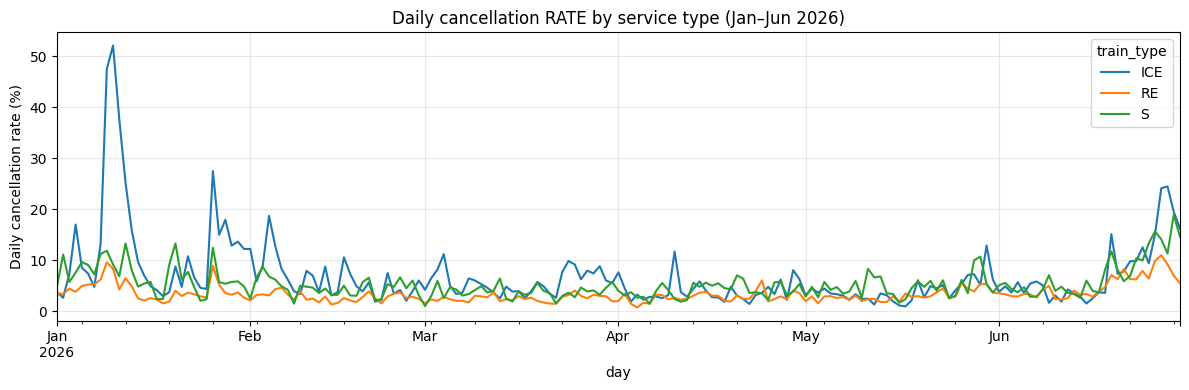

In [8]:
rate_by_day = con.execute(f"""
    SELECT
        date_trunc('day', time)                    AS day,
        train_type,
        count(*)                                   AS scheduled_stops,
        sum(is_canceled::int)                      AS cancelled_stops,
        100.0 * sum(is_canceled::int) / count(*)   AS cancel_pct
    FROM read_parquet('{DATA_GLOB}')
    WHERE train_type IN ('ICE', 'RE', 'S')
      AND time >= '{ANALYSIS_START}' AND time < '{ANALYSIS_END}'
    GROUP BY day, train_type
    ORDER BY day
""").df()

pivoted = rate_by_day.pivot(index='day', columns='train_type', values='cancel_pct')
pivoted.plot(figsize=(12, 4))
plt.ylabel('Daily cancellation rate (%)')
plt.title('Daily cancellation RATE by service type (Jan–Jun 2026)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Data limitations

- **No cancellation reason** — `is_canceled` is a bare boolean; the *why* of any spike needs external data (weather, strike records), so causes stay hypotheses until verified.
- **Coverage break at 2025-11-02** — ~100 stations before, all after; cross-era comparison is invalid, which is why the window is confined to 2026.
- **Missing collection hours** — an absent row does not mean no train ran.
- **Stops ≠ trains** — counts are per stop; one cancelled long-route train contributes many rows.
- **Timestamps are Europe/Berlin** — mind DST for hour-of-day work across late March / late October.

## 6. Conclusion of the EDA

**What the EDA established:**
1. Punctuality runs on a daily cycle — best pre-dawn ~95%, worst in the evening peak ~80%.
2. Long-distance/international services trail regional ones on punctuality.
3. Cancellations are event-driven, and long-distance services are hit far harder than regional ones — on disruption days ICE cancellation rate spikes well above RE and S-Bahn (~50% vs ~10% around 9–12 Jan). Regional services rise slightly on those days, so the disruptions aren't purely long-distance, but ICE's response is several times larger.

**What this points to.** Observation (1) and (2) both hint at the same mechanism: delay
accumulating over the course of a journey. The EDA cannot confirm that, because every
query above treats each stop independently. That is the question worth a dedicated
analysis.

**Decision — the analysis will investigate DELAY COMPOUNDING:**

> On average, how many minutes does a train gain or lose *per stop* as it travels along its
> route. Which routes systematically recover versus systematically spiral?

This is answerable inside the dataset using `train_line_ride_id` (which journey a stop
belongs to) and `train_line_station_num` (the stop's position in that journey), and it is
a question the dataset's existing public statistics do not address.